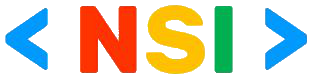
<div style="color:white;border-collapse:separate;border:solid 2px;border-radius:14px;border-color:Darkred;background-color:darkred;width:100%;">
    <div style="display:flex;">
        <div style="display:inline;width:20%;text-align:left;padding-left: 10px;"><b>Laura Fléron</b></div>
        <div style="display:inline;width:60%;text-align:center"></div>
        <div style="display:inline;width:20%;text-align:right;padding-right: 10px;"><b>NSI</b></div>
    </div>
        <h1 style="width:100%;text-align:center;">SQL - Escape Game</h1>
        <h1 style="width:100%;text-align:center;">Quête 1 : Le Repaire de l'Ombre</h1>
    <div  style="display: flex;">
         <div style="display:inline;width:20%;text-align:left;padding-left: 10px;">&#160; </div>
        <div style="display:inline;width:60%;text-align:center">&#160; </div>
        <div style="display:inline;width:20%;text-align:right;padding-right: 10px;">&#160;</div>
    </div>
</div>

# L'Unité spéciale gouvernementale O.M.B.R.E.

**O**rganisation de **M**onitorage des **B**rèches et de **R**echerche **E**nvironnementale.

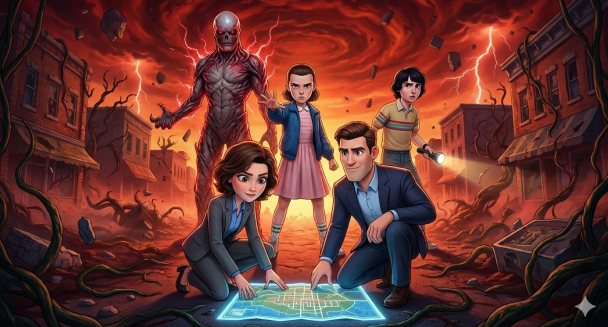

??? warning À l'attention de l'unité spéciale d'enquête.

Bienvenue, agents. Vous venez d'être dépêchés pour faire toute la lumière sur les événements paranormaux qui frappent la ville de **Hawkins**.

**Voici vos badges pour cette mission :**

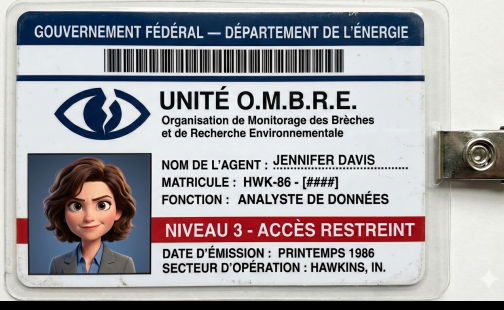 - 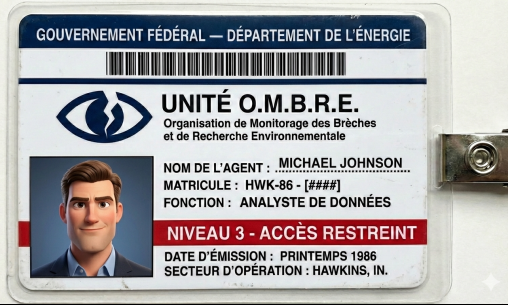

???

---

# 🕵️‍♂️ Rapport d'Intervention : Dossier Hawkins


??? tip 📜 Résumé des Événements (1983 - 1986)

L'histoire commence par une anomalie : la disparition soudaine du jeune **Will Byers**.

Cette enquête a révélé l'existence d'un **Laboratoire** secret où des expériences étaient menées sur des enfants, notamment sur une jeune fille nommée **Eleven**, dotée de pouvoirs de **télékinésie**.

Le danger ne vient pas seulement de notre monde. Un univers parallèle toxique accéssible par un trou de ver tente de s'infiltrer à Hawkins.

Au fil des années, la menace a grandi :

* Des créatures ont envahi la ville par la forêt.
* Une bataille majeure a détruit le centre commercial **Starcourt Mall** en 1985.
* Aujourd'hui, une entité plus sombre et intelligente semble diriger ces attaques depuis une mystérieuse demeure.

???

??? tip 🎯 Agents, voici votre Mission

Votre rapport doit identifier précisément le point d'ancrage de cette menace. Nous savons que l'entité (identifié comme le sujet possédant des "Pouvoirs psychiques") est lié à **un lieu** spécifique lors des tragiques événements du **printemps 1986**.

Vous allez devoir fouiller les archives numériques étape par étape pour ne laisser aucun indice au hasard. Les rapports de **Jim Hopper**, cherif du conté de Hawkings, sont complétés d'une base de données. La sécurité de la ville ainsi de les actions à mener dans le futur dépend de la précision de votre rapport.
???

??? example 🛠️ Matériel de l'enquêteur

Pour mener à bien vos recherches, vous avez accès à l'ensemble de la base de données mais deux archives semblent surtout importantes pour votre mission :

* **La Table `Lieu` :** C'est le cadastre de la ville. Elle répertorie chaque endroit (maisons, écoles, bâtiments publics) et précise son type.

* **La Table `Apparition` :** C'est votre journal de bord le plus précieux. Chaque ligne est un témoignage qui lie un **personnage** à un **lieu** précis lors d'un **épisode** qui a eu lieu à un moment donné. C'est grâce à cette table dans la base de données que vous pourrez retracer les mouvements de l'entité.

* **D'autres bases** pourront être consultées pour comprendre le déroulé des évènements et trouver le lieu à neutraliser.

**Jim Hopper a laissé un plan de la structure de l'organisation des données sur son ordinateur de bureau**

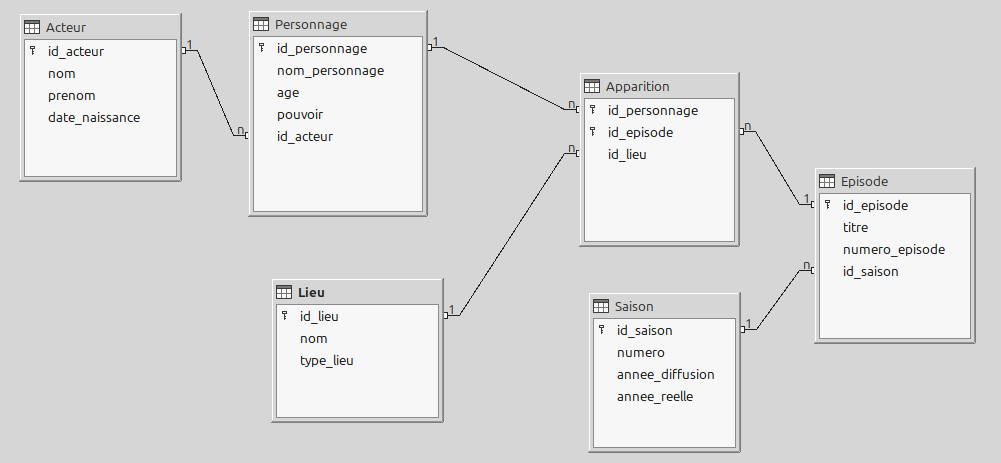

???

## Cette mission est elle impossible pour vous ?

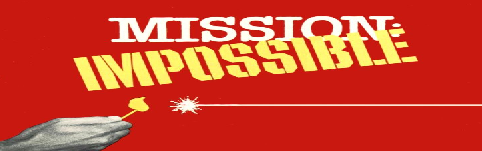
---


## 🕵️ Mission 1 : Le Repaire de l'Ombre

**Le but :** Vous devez trouver le nom du lieu où se cache l'entité qui trouble le conté de Hawkings afin d'envoyer les troupes militaires.


!!! warning Identifier le suspect

Vous retrouvez, dans le carnet de notes, de **Jim hoper**, une note : 

> ce suspect a de réels `Pouvoirs psychiques`...

**La table `Personnage` pourrait bien vous aider !**

!!!

In [ ]:
-- Personnages possédant un pouvoir
SELECT nom_personnage, pouvoir
FROM Personnage
WHERE pouvoir = 'Pouvoirs psychiques';

!!! warning Recouper votre résultat...

Vous retouvez aussi, dans le carnet de notes de **Jim hoper** deux chiffres : 

> 1 & 4

Pourquoi ces chiffres ?

Un **numéro d'identification** peut être ?

!!!

In [ ]:
SELECT id_personnage AS personnage
FROM Personnage 
WHERE nom_personnage = 'Vecna';

In [ ]:
SELECT nom_personnage AS personnage
FROM Personnage 
WHERE id_personnage = 14;

??? example Solution : Identifier le suspect
Avant tout, nous avons besoin du numéro d'identification (ID) du suspect dans les archives.

> **Requête :** Trouve l' `id_personnage` de **Vecna**.

```sql
SELECT id_personnage 
FROM Personnage 
WHERE nom_personnage = 'Vecna';
```
* **Résultat attendu :** `id_personnage` = **14**.
* **Note :** Le personnage de Vecna est bien enregistré avec cet identifiant unique dans la table `Personnage`.

On peut aussi procéder *à l'envers* :

```sql
SELECT nom_personnage AS personnage
FROM Personnage 
WHERE id_personnage = 14;
```

* **Résultat :** `nom_personnage` = Vecna.
???

---

!!! warning A quelle saison les évènements sont ils associés ?

Jim, toujours dans sont carnet évoque **l'année 1986**. C'est certainnement à cette période que les évènements ont commencé.

On sait aussi que Jim a associé cette période à **une saison**.

**Trouvez l'année réelle de cette `saison` !**

!!!

In [ ]:
-- année réelle 1986
SELECT numero AS saison
FROM Saison
WHERE annee_reelle = 1986;

---

!!! warning Quelles sont les épisodes associés à cette année réelle ?

Jim, note beaucoup d'informations !

C'est bien 👍️ mais nous devons maintenant savoir quels sont les évènements (**`episode`**) qui sont survenus durant cette année.

!!!

In [ ]:
-- Titres des épisodes pour la saison 4
SELECT id_episode, titre
FROM Episode
WHERE id_saison = 4
ORDER BY id_episode;

??? example Solution : Identifier la période

```sql
SELECT numero AS saison
FROM Saison
WHERE annee_reelle = 1986;

```

* **Résultat attendu :** Une liste d'identifiants allant de **26** à **34**.
* **Note :** Ces numéros correspondent à tous les chapitres de la saison 4, de "Le Club de l’Enfer" au "Monde à l’envers".
???

!!! warning Où le suspect était-il au moment de ces épisodes ?

Allez ! encore une petit effort !

Où se trouvait le suspect durant ces épisodes ?

La table `Apparition` semble parfaite pour croiser ce type d'informations 🤔.

Il nous faut trouver le ou les lieux où le suspect était présent au moment des faits !

!!!

In [ ]:
SELECT id_episode, id_personnage, id_lieu
FROM Apparition 
WHERE id_personnage = 14
  AND id_episode BETWEEN 26 AND 34;

!!! warning `Eleven` et `Mike Weeler` était présents au moment des évènements !

**Jim** est formel 👮‍♂️, dans son carnet, il mentionne la présence de `Eleven` et `Mike`. Dans la base, ils portent aussi un `id` !

**Trouvez leurs identifiants !**

!!!

In [ ]:
SELECT id_personnage, nom_personnage
FROM Personnage
WHERE nom_personnage = 'Eleven' OR nom_personnage = 'Mike Wheeler'

!!! warning Ils étaient donc présents avec le suspect à cet endroit 🤔.

Vous touchez au but maintenant.

**Quel ce lieu ?**
!!!

In [ ]:
SELECT id_personnage, id_lieu
FROM Apparition 
WHERE (id_personnage = 1 OR id_personnage = 2 OR id_personnage = 14)
    AND id_episode BETWEEN 26 AND 34;

??? example Solution : Quel est le lieu où sont présents les personnages

* **Résultat attendu :** Une liste de personnages et d'endroits possibles.
* Un seul endroit est possible regroupant des 3 personnages.
* c'est le lieu **8**
???

!!! warning Un seul lieu est possible

**Donnez le nom de ce lieu**

!!!

In [ ]:
SELECT DISTINCT id_lieu, nom
FROM Lieu
WHERE id_lieu = 8

!!! question Résultat de l'enquête 🏆

ALors ?

Où allez vous envoyer les forces militaires ?

!!!

---


??? example Solution : LE LIEU

* Le lieu à trouver est l'**Upside Down**.
???

### Voici une solution de pro, merci Gemini 👾.

Pour info, ce n'est pas au programme 😄.


In [ ]:
-- Cette requête principale donne toutes solutions
SELECT DISTINCT id_personnage, id_lieu
FROM Apparition
WHERE id_personnage IN (1, 2, 14)
  AND id_episode BETWEEN 26 AND 34
  AND id_lieu IN (
      -- Cette sous-requête trouve l'id_lieu commun aux 3 personnages
      SELECT id_lieu
      FROM Apparition
      WHERE id_personnage IN (1, 2, 14)
        AND id_episode BETWEEN 26 AND 34
      GROUP BY id_lieu
      HAVING COUNT(DISTINCT id_personnage) = 3
  );

??? example Explication :

La requête principale donne la liste de toutes les solutions.

La sous-requête prend en entrée la liste principale pour la retraiter.

`HAVING COUNT(DISTINCT id_personnage) = 3` : C'est le filtre. On ne garde que les lieux où le nombre de personnages différents est égal à 3, les autres possibilités n'étant pas prisent en compte.

**On cherche l'intersection :**
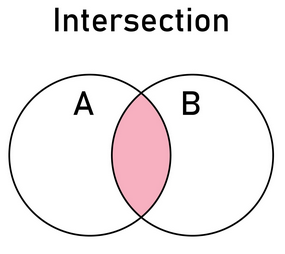
???

#### Les prochaines activités seront consacrées aux requêtes avec jointures !

#### Tout un programme...

??? note Crédits
Laura Fléron 
26/01/2026
Version 1
???

## Voilà c'est tout pour aujourd'hui
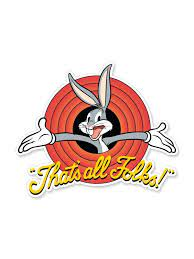